# Глава 5

## Задание 5.1

In [2]:


import pandas as pd
import numpy as np
import os
import sys

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)


df = pd.read_csv("BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv", parse_dates=[0])
ys = df["USD"]
ts = df.index



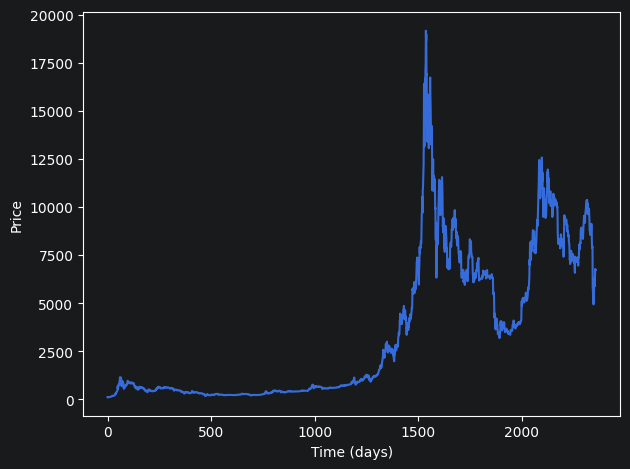

In [5]:
from thinkdsp import Wave, decorate


wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel="Time (days)", ylabel="Price")

In [6]:
def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[: n - lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]

def autocorr(wave):
    lags = np.arange(len(wave.ys) // 2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

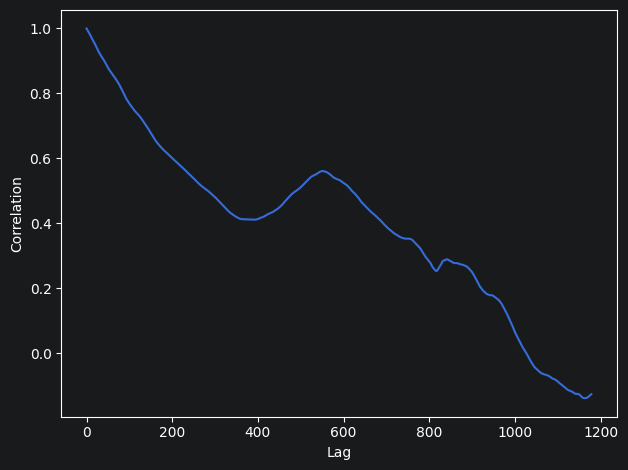

In [7]:
import matplotlib.pyplot as plt


lags, corrs = autocorr(wave)
plt.plot(lags, corrs)
decorate(xlabel="Lag", ylabel="Correlation")



## Задание 5.2

In [13]:
def estimate_fundamental(segment, low=70, high=150):
    lags, corrs = autocorr(segment)
    lag = np.array(corrs[low:high]).argmax() + low
    period = lag / segment.framerate
    frequency = 1 / period
    return frequency

In [14]:
from thinkdsp import read_wave

wave = read_wave("328878__tzurkan__guitar-phrase-tzu.wav")
wave.normalize()
wave.make_audio()


In [15]:
duration = 0.01
segment = wave.segment(start=0.2, duration=duration)
freq = estimate_fundamental(segment)
freq

np.float64(630.0)

## Задание 5.3

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import Wave, decorate

df = pd.read_csv("BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv", parse_dates=[1])

ys = df['Closing Price (USD)'].values
ts = np.arange(len(ys))
wave = Wave(ys, framerate=1)

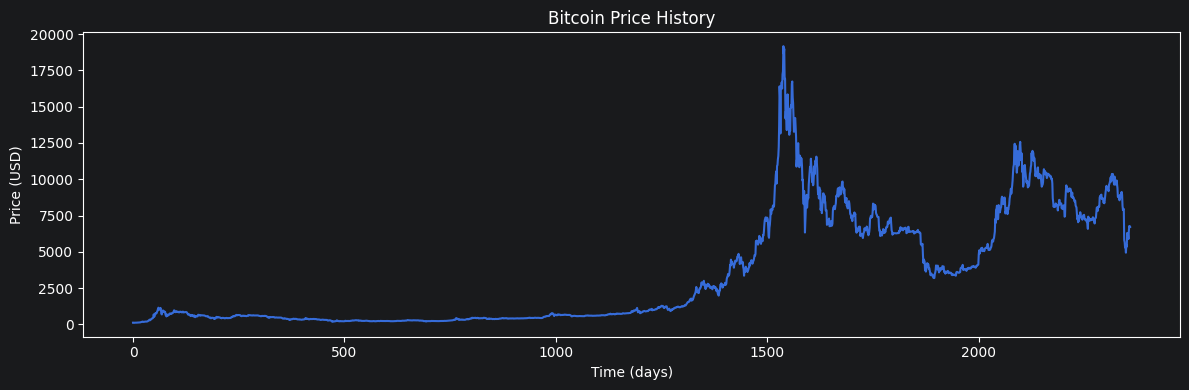

In [18]:
plt.figure(figsize=(12, 4))
wave.plot()
decorate(xlabel="Time (days)", ylabel="Price (USD)", title="Bitcoin Price History")
plt.show()

In [19]:
def serial_corr(wave, lag=1):
    n = len(wave)
    y1 = wave.ys[lag:]
    y2 = wave.ys[:n - lag]
    corr_mat = np.corrcoef(y1, y2)
    return corr_mat[0, 1]


In [20]:
def autocorr(wave):
    lags = np.arange(len(wave.ys) // 2)
    corrs = [serial_corr(wave, lag) for lag in lags]
    return lags, corrs

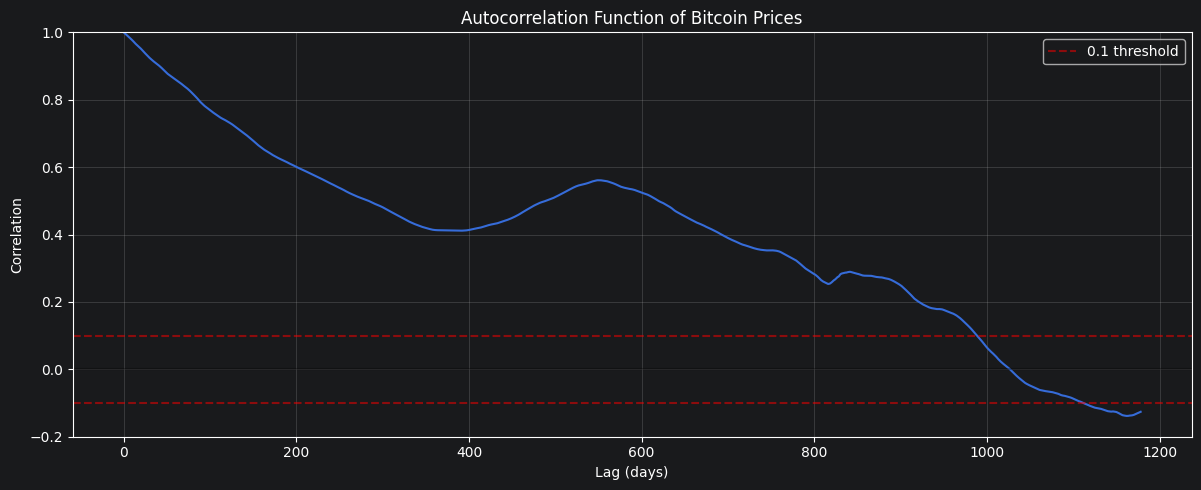

In [21]:
plt.figure(figsize=(12, 5))
lags, corrs = autocorr(wave)
plt.plot(lags, corrs)
decorate(xlabel="Lag (days)", ylabel="Correlation", title="Autocorrelation Function of Bitcoin Prices")
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='0.1 threshold')
plt.axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
plt.ylim(-0.2, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


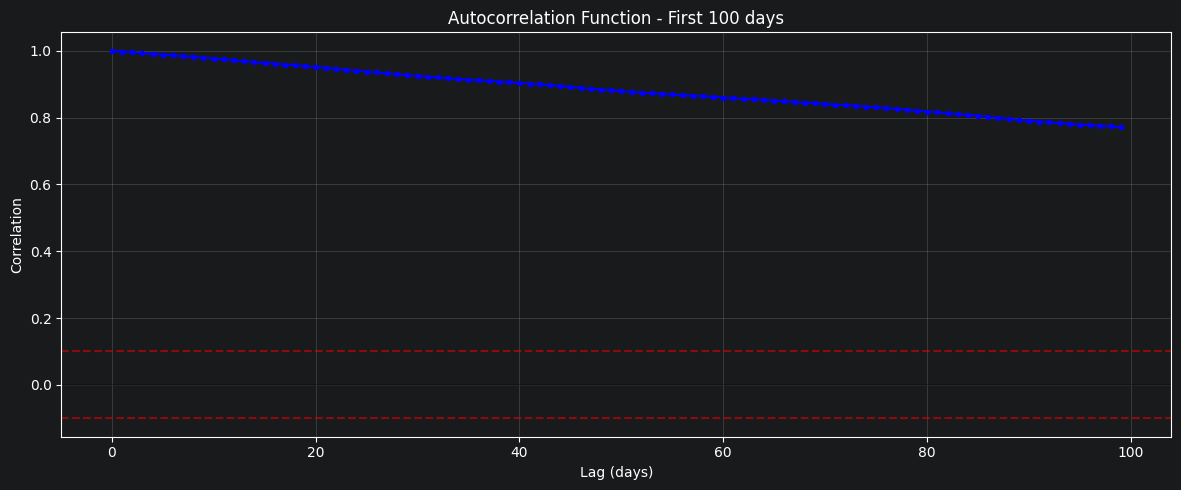

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(lags[:100], corrs[:100], 'b-o', markersize=3)
decorate(xlabel="Lag (days)", ylabel="Correlation", title="Autocorrelation Function - First 100 days")
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

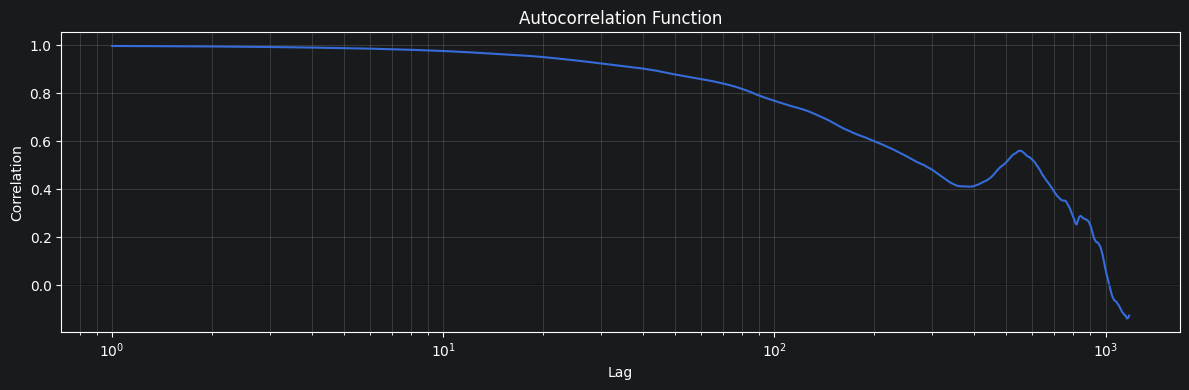

In [24]:




from scipy.signal import find_peaks


peaks, properties = find_peaks(corrs[:500], height=0.1, distance=30)
if len(peaks) > 0:
    if len(peaks) > 1:
        periods = np.diff(lags[:500][peaks])

plt.figure(figsize=(12, 4))
plt.semilogx(lags[1:], corrs[1:])
decorate(xlabel="Lag", ylabel="Correlation",title="Autocorrelation Function")
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3, which='both')
plt.show()


 СКОРОСТЬ СПАДА АВТОКОРРЕЛЯЦИИ:
   - Автокорреляция спадает медленно
   - Значительная корреляция сохраняется на протяжении многих дней

 ПРИЗНАКИ ПЕРИОДИЧНОСТИ:
   - Нет явно выраженных периодических паттернов

 ФИЗИЧЕСКИЙ СМЫСЛ:
   - Инерционность рынка: сегодняшние цены зависят от вчерашних
   - Долговременная память может объясняться: